# COOLANT — Threshold Tuning (eval-only, không train)

Load `best_macro_f1.pth` đã train → sweep ngưỡng P(fake) trên **dev** → áp cố định lên **test**.

Mặc định argmax/0.5: fake precision ≈0.99, recall ≈0.82. Tune ngưỡng trên dev only để tránh test leakage.

**Chạy tuần tự từ trên xuống.**


In [1]:
# ── Environment + path setup ────────────────────────────────────────────────
import os, sys
from pathlib import Path


def _detect_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/input").exists():
        return "kaggle"
    try:
        import google.colab

        return "colab"
    except ImportError:
        pass
    if Path("/workspace").exists():
        return "vastai"
    if sys.platform == "darwin":
        return "mac"
    return "windows"


PLATFORM = _detect_platform()

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
elif PLATFORM == "kaggle":
    PROJECT_ROOT = Path(
        os.environ.get("KAGGLE_PROJECT_ROOT", "/kaggle/working/fake-news-detection")
    )
else:
    PROJECT_ROOT = (
        _nb_path.parents[1]
        if _nb_path.name.endswith(".ipynb")
        else Path.cwd().parents[1]
    )

sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv

_env_file = PROJECT_ROOT / f".env.{PLATFORM}"
if not _env_file.exists():
    _env_file = PROJECT_ROOT / ".env"
load_dotenv(_env_file, override=True)

from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()
print(f"Platform : {PLATFORM}")
print(f"DATA_ROOT: {DATA_ROOT}  (exists={DATA_ROOT.exists()})")

Platform : mac
DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis  (exists=True)


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from src.models.coolant_official import COOLANT_Official
from src.preprocessing.coolant.pair_dataset import create_coolant_dataloaders
from src.preprocessing.coolant.training_utils import make_detection_batch

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"PyTorch: {torch.__version__}  |  Device: {DEVICE}")

PyTorch: 2.12.0  |  Device: mps


In [3]:
# ── Checkpoint + model config (khớp run đã train) ───────────────────────────
# Chỉnh path tới best checkpoint muốn eval
CHECKPOINT_PATH = Path(
    "/Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com"
    "/My Drive/Thesis_Final/fake-news-data-for-thesis/training"
    "/coolant_20260908_COOLANT_GATEDMLP/best_macro_f1.pth"
)
# Ví dụ Kaggle dataset: Path("/kaggle/input/coolant-v2-best/best_macro_f1.pth")

model_cfg = {
    "text_input_dim": 768,
    "image_input_dim": 2048,
    "text_seq_len": 128,
    "shared_dim": 128,
    "sim_dim": 64,
    "feature_dim": 96,
    "h_dim": 64,
    "use_itc": True,
    "clip_embed_dim": 64,
    "sem_weight": 1.0,
    "itm_weight": 0.5,
}

BATCH_SIZE = 32
DET_SHIFT = 3  # shift trong make_detection_batch, khớp evaluate() của training

In [4]:
# ── Dataloaders (chỉ cần dev + test) ─────────────────────────────────────────
loaders, datasets = create_coolant_dataloaders(
    str(DATA_ROOT / "processed_data" / "hdf5" / "coolant_train.h5"),
    str(DATA_ROOT / "processed_data" / "hdf5" / "coolant_dev.h5"),
    str(DATA_ROOT / "processed_data" / "hdf5" / "coolant_test.h5"),
    batch_size=BATCH_SIZE,
)
print({k: len(v) for k, v in datasets.items()})

CoolantPairDataset: 6724 pairs from coolant_train.h5
CoolantPairDataset: 862 pairs from coolant_dev.h5
CoolantPairDataset: 2053 pairs from coolant_test.h5

COOLANT DataLoaders created:
  Train: 211 batches (6724 pairs)
  Dev:   27 batches (862 pairs)
  Test:  65 batches (2053 pairs)
{'train': 6724, 'dev': 862, 'test': 2053}


In [5]:
# ── Load best checkpoint ────────────────────────────────────────────────────
model = COOLANT_Official(model_cfg).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded: {CHECKPOINT_PATH.name}")
print(
    f"  epoch={ckpt['epoch']}  use_itc={ckpt.get('use_itc')}  "
    f"val_macro_f1={ckpt['metrics'].get('val_macro_f1')}"
)

Loaded: best_macro_f1.pth
  epoch=49  use_itc=True  val_macro_f1=0.9300555552550295


In [6]:
# ── Inference helper — cùng path với evaluate() trong training ──────────────
def _get_det_features(m, caption, image):
    if m.use_itc:
        return m.clip_module(caption, image)
    return m.similarity_module(caption, image)[:2]


@torch.no_grad()
def collect_probs(m, loader):
    """Trả về (y_true, P(fake))."""
    ys, ps = [], []
    for caption, image, _ in loader:
        caption, image = caption.to(DEVICE), image.to(DEVICE)
        dc, di, dl = make_detection_batch(caption, image, shift=DET_SHIFT)
        dc, di, dl = dc.to(DEVICE), di.to(DEVICE), dl.to(DEVICE)
        m_t, m_v = _get_det_features(m, dc, di)
        det_logits, _, _ = m.detection_module(dc, di, m_t, m_v)
        ps.append(F.softmax(det_logits, dim=1)[:, 1].cpu())
        ys.append(dl.cpu())
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

Best dev threshold = 0.30
threshold      0.300000
fake_f1        0.933170
fake_recall    0.882831
fake_prec      0.989597
macro_f1       0.936590


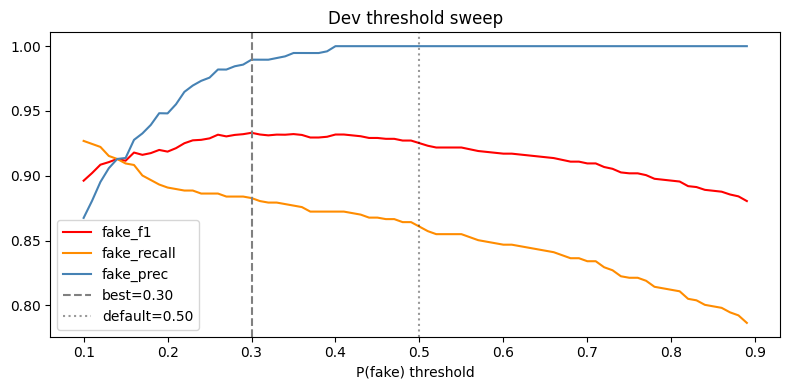

In [7]:
# ── Sweep threshold trên DEV (chọn ngưỡng — KHÔNG dùng test) ───────────────
y_dev, p_dev = collect_probs(model, loaders["dev"])

rows = []
for t in np.arange(0.10, 0.90, 0.01):
    preds = (p_dev >= t).astype(int)
    rows.append(
        {
            "threshold": round(float(t), 2),
            "fake_f1": f1_score(y_dev, preds, pos_label=1, zero_division=0),
            "fake_recall": recall_score(y_dev, preds, pos_label=1, zero_division=0),
            "fake_prec": precision_score(y_dev, preds, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_dev, preds, average="macro", zero_division=0),
        }
    )
sweep_df = pd.DataFrame(rows)
best_row = sweep_df.loc[sweep_df.fake_f1.idxmax()]
best_threshold = float(best_row.threshold)

print(f"Best dev threshold = {best_threshold:.2f}")
print(best_row.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for col, c in [
    ("fake_f1", "red"),
    ("fake_recall", "darkorange"),
    ("fake_prec", "steelblue"),
]:
    ax.plot(sweep_df.threshold, sweep_df[col], label=col, color=c)
ax.axvline(best_threshold, ls="--", c="gray", label=f"best={best_threshold:.2f}")
ax.axvline(0.5, ls=":", c="black", alpha=0.4, label="default=0.50")
ax.set_xlabel("P(fake) threshold")
ax.set_title("Dev threshold sweep")
ax.legend()
plt.tight_layout()
plt.show()


══ TEST — default @0.50 ══
  accuracy  = 0.9062
  macro-F1  = 0.9056
  fake P/R/F1 = 0.9854 / 0.8246 / 0.8979
  real P/R/F1 = 0.8492 / 0.9878 / 0.9133

══ TEST — tuned @0.30 ══
  accuracy  = 0.9128
  macro-F1  = 0.9125
  fake P/R/F1 = 0.9695 / 0.8524 / 0.9072
  real P/R/F1 = 0.8683 / 0.9732 / 0.9178
Saved → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/coolant_20260908_COOLANT_GATEDMLP/test_cm_tuned.png


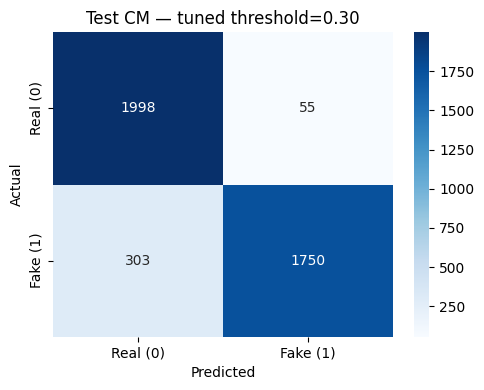

In [8]:
# ── TEST evaluation với threshold đã chọn trên dev ──────────────────────────
y_test, p_test = collect_probs(model, loaders["test"])

for name, t in [
    ("default @0.50", 0.5),
    (f"tuned @{best_threshold:.2f}", best_threshold),
]:
    preds = (p_test >= t).astype(int)
    print(f"\n══ TEST — {name} ══")
    print(f"  accuracy  = {(preds == y_test).mean():.4f}")
    print(f"  macro-F1  = {f1_score(y_test, preds, average='macro'):.4f}")
    print(
        f"  fake P/R/F1 = {precision_score(y_test, preds, pos_label=1, zero_division=0):.4f} / "
        f"{recall_score(y_test, preds, pos_label=1, zero_division=0):.4f} / "
        f"{f1_score(y_test, preds, pos_label=1, zero_division=0):.4f}"
    )
    print(
        f"  real P/R/F1 = {precision_score(y_test, preds, pos_label=0, zero_division=0):.4f} / "
        f"{recall_score(y_test, preds, pos_label=0, zero_division=0):.4f} / "
        f"{f1_score(y_test, preds, pos_label=0, zero_division=0):.4f}"
    )
    if t != 0.5:
        cm_t = confusion_matrix(y_test, preds, labels=[0, 1])
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(
            cm_t,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Real (0)", "Fake (1)"],
            yticklabels=["Real (0)", "Fake (1)"],
            ax=ax,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"Test CM — tuned threshold={best_threshold:.2f}")
        plt.tight_layout()
        out = CHECKPOINT_PATH.parent / "test_cm_tuned.png"
        try:
            fig.savefig(out, dpi=120, bbox_inches="tight")
            print(f"Saved → {out}")
        except OSError as e:
            print(f"(không ghi được PNG: {e})")
        plt.show()

In [9]:
# ── Lưu kết quả threshold tuning ────────────────────────────────────────────
out_json = CHECKPOINT_PATH.parent / "threshold_tuning.json"
try:
    out_json.write_text(
        json.dumps(
            {
                "checkpoint": str(CHECKPOINT_PATH),
                "ckpt_epoch": int(ckpt["epoch"]),
                "threshold": best_threshold,
                "dev_fake_f1": float(best_row.fake_f1),
                "sweep": rows,
            },
            indent=2,
        )
    )
    print(f"Saved → {out_json}")
except OSError as e:
    print(f"(không ghi được JSON: {e})")

Saved → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/coolant_20260908_COOLANT_GATEDMLP/threshold_tuning.json
